# Exploratory Data Analysis (EDA)

This notebook performs a minimal exploratory data analysis on the raw `sample.csv` artifact downloaded from Weights & Biases. The goal is to identify obvious data quality issues (missing values, outliers, wrong types) that need to be addressed in the `basic_cleaning` step of the pipeline.

In [1]:
import wandb
import pandas as pd

run = wandb.init(project="nyc_airbnb", group="eda", save_code=True)
local_path = wandb.use_artifact("sample.csv:latest").file()
df = pd.read_csv(local_path)

/home/student/.conda/envs/mlflow-6f02ff4842fbe0d4c84a3c2da9d0eede237ec11e/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/student/.conda/envs/mlflow-6f02ff4842fbe0d4c84a3c2da9d0eede237ec11e/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model

wandb: Currently logged in as: yusuke-ma64 (yusuke-ma64-udacity) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: creating run


wandb: Tracking run with wandb version 0.21.3


wandb: Run data is saved locally in /workspace/build-ml-pipeline-for-short-term-rental-prices/src/eda/wandb/run-20260630_033234-sxou0bl2
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run ancient-snow-29


wandb: ⭐️ View project at https://wandb.ai/yusuke-ma64-udacity/nyc_airbnb


wandb: 🚀 View run at https://wandb.ai/yusuke-ma64-udacity/nyc_airbnb/runs/sxou0bl2


## Basic overview

Let's look at the shape of the dataset, the column types, and a sample of rows.

In [2]:
df.shape

(20000, 16)

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9138664,Private Lg Room 15 min to Manhattan,47594947,Iris,Queens,Sunnyside,40.74271,-73.92493,Private room,74,2,6,2019-05-26,0.13,1,5
1,31444015,TIME SQUARE CHARMING ONE BED IN HELL'S KITCHEN...,8523790,Johlex,Manhattan,Hell's Kitchen,40.76682,-73.98878,Entire home/apt,170,3,0,NaN,NaN,1,188
2,8741020,Voted #1 Location Quintessential 1BR W Village...,45854238,John,Manhattan,West Village,40.73631,-74.00611,Entire home/apt,245,3,51,2018-09-19,1.12,1,0
3,34602077,Spacious 1 bedroom apartment 15min from Manhattan,261055465,Regan,Queens,Astoria,40.76424,-73.92351,Entire home/apt,125,3,1,2019-05-24,0.65,1,13
4,23203149,Big beautiful bedroom in huge Bushwick apartment,143460,Megan,Brooklyn,Bushwick,40.69839,-73.92044,Private room,65,2,8,2019-06-23,0.52,2,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  int64  
 1   name                            19993 non-null  object 
 2   host_id                         20000 non-null  int64  
 3   host_name                       19992 non-null  object 
 4   neighbourhood_group             20000 non-null  object 
 5   neighbourhood                   20000 non-null  object 
 6   latitude                        20000 non-null  float64
 7   longitude                       20000 non-null  float64
 8   room_type                       20000 non-null  object 
 9   price                           20000 non-null  int64  
 10  minimum_nights                  20000 non-null  int64  
 11  number_of_reviews               20000 non-null  int64  
 12  last_review                     

## Missing values

We can see that there are missing values in a few columns, most notably `name`, `host_name`, `last_review`, and `reviews_per_month`. Also note that `last_review` is stored as a string, not as a date.

In [5]:
df.isnull().sum()

id                                   0
name                                 7
host_id                              0
host_name                            8
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       4123
reviews_per_month                 4123
calculated_host_listings_count       0
availability_365                     0
dtype: int64

## Price distribution and outliers

Let's look at the `price` column more closely, since this is our target variable.

In [6]:
df['price'].describe()

count    20000.000000
mean       153.269050
std        243.325609
min          0.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

<Axes: >

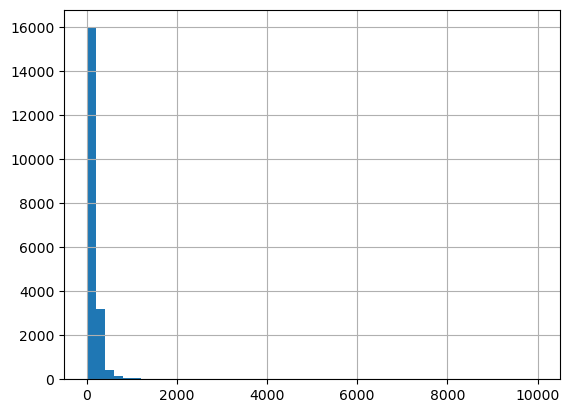

In [7]:
df['price'].hist(bins=50)

There are some prices equal to zero, which do not make sense for a rental listing, as well as some very high prices that are likely outliers or data entry mistakes. After discussing with stakeholders, we decide to consider only listings priced between $10 and $350 per night as valid for this exercise.

In [8]:
min_price = 10
max_price = 350

idx = df['price'].between(min_price, max_price)
df = df[idx].copy()

# Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19001 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19001 non-null  int64         
 1   name                            18994 non-null  object        
 2   host_id                         19001 non-null  int64         
 3   host_name                       18993 non-null  object        
 4   neighbourhood_group             19001 non-null  object        
 5   neighbourhood                   19001 non-null  object        
 6   latitude                        19001 non-null  float64       
 7   longitude                       19001 non-null  float64       
 8   room_type                       19001 non-null  object        
 9   price                           19001 non-null  int64         
 10  minimum_nights                  19001 non-null  int64         
 11  number_

Note that we do not impute missing values here. Imputation will be handled inside the inference pipeline (in the `train_random_forest` step), so that the same logic also applies in production when new data comes in.

## Geographic boundaries

Since this dataset is about NYC properties, we also check that the latitude/longitude values fall within the expected boundaries of New York City, which is later enforced as a data check (`test_proper_boundaries`).

In [9]:
df['longitude'].describe(), df['latitude'].describe()

(count    19001.000000
 mean       -73.950827
 std          0.046825
 min        -74.239140
 25%        -73.982050
 50%        -73.954630
 75%        -73.934490
 max        -73.717950
 Name: longitude, dtype: float64,
 count    19001.000000
 mean        40.728063
 std          0.055389
 min         40.508730
 25%         40.688820
 50%         40.721710
 75%         40.763210
 max         40.913060
 Name: latitude, dtype: float64)

## Neighbourhood groups and room types

Let's also check the categorical columns that we will use for stratification and feature engineering later in the pipeline.

In [10]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Brooklyn         8046
Manhattan        8031
Queens           2331
Bronx             434
Staten Island     159
Name: count, dtype: int64

In [11]:
df['room_type'].value_counts()

room_type
Entire home/apt    9522
Private room       9041
Shared room         438
Name: count, dtype: int64

## Summary

From this exploratory analysis we conclude:

- The dataset contains missing values in `name`, `host_name`, `last_review`, and `reviews_per_month`. These will be handled via imputation inside the modeling pipeline rather than dropped here, so the same logic also works in production.
- The `price` column contains outliers (zeros and very high values). We filter to the $10-$350 range, which becomes the `min_price`/`max_price` parameters of the `basic_cleaning` step.
- `last_review` needs to be converted from string to datetime.
- `neighbourhood_group` and `room_type` are the main categorical features, and `neighbourhood_group` is used later to stratify the train/validation/test split.

These findings directly inform the implementation of the `basic_cleaning` component of the pipeline.

In [12]:
run.finish()

wandb: updating run metadata


wandb:                                                                                


wandb: 🚀 View run ancient-snow-29 at: https://wandb.ai/yusuke-ma64-udacity/nyc_airbnb/runs/sxou0bl2
wandb: ⭐️ View project at: https://wandb.ai/yusuke-ma64-udacity/nyc_airbnb
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260630_033234-sxou0bl2/logs
